# 05 · Monitoreo operacional y selección de muestras para el nuevo ciclo

Lee el `metrics.json` de una corrida (volumen, rendimiento, calidad, segmentación y trazabilidad) y selecciona muestras
(baja confianza, errores, sin detección, alta confianza) para reetiquetar y reentrenar.

In [1]:
import sys
from pathlib import Path

_nb = Path.cwd() if (Path.cwd() / "helpers.py").exists() else Path.cwd() / "notebooks"
sys.path.insert(0, str(_nb))
from helpers import *   # utilidades compartidas (pd, plt, np, run, read_json, show_images...)

REPO = setup()          # cambia el directorio de trabajo a la raíz del repo
print("Repositorio:", REPO)

Repositorio: /home/usuario/Code/Projects/Computer Vision Projects/PPE-detection-using-computer-vision


In [2]:
RUN_DIR    = env("RUN_DIR", "outputs/latest")
EVAL_DIR   = env("EVAL_DIR", "reports/evaluation")
SAMPLES_CSV = env("SAMPLES_CSV", "reports/next_cycle_samples.csv")
N_SAMPLES  = 100
RUN_SELECT = True

In [3]:
run_dir = Path(RUN_DIR)
ready = exists_or_hint(run_dir / "metrics.json", "Ejecuta scripts/inference.py.")
if ready:
    m = read_json(run_dir / "metrics.json")
    preds = read_jsonl_df(run_dir / "predictions.jsonl")
    index = read_jsonl_df(run_dir / "images_index.jsonl")

## 1. Volumen y rendimiento

In [4]:
if ready:
    display(pd.Series(m["volume"], name="volumen").to_frame())
    perf = {k: v for k, v in m["performance"].items() if k != "failed_files"}
    display(pd.Series(perf, name="rendimiento").to_frame())
    print("Archivos fallidos:", m["performance"]["failed_files"] or "ninguno")

,volumen
files_found,406
files_processed,406
files_failed,0
videos,0
frames,406
detections,2811
events,655


,rendimiento
total_seconds,33.784
mean_ms_per_frame,83.03
mean_inference_ms,78.18
p95_inference_ms,14.57
mean_read_preprocess_ms,4.3
fps_end_to_end,12.02
fps_inference_only,12.79
interrupted,False


Archivos fallidos: ninguno


## 2. Calidad: confianza por clase, descartes y distribución de clases

In [5]:
if ready:
    q = m["quality"]
    display(pd.DataFrame(q["confidence_by_class"]).T)
    display(pd.DataFrame(q["class_distribution"]).T)
    print("Descartes:", q["discarded"])
    print("Imágenes sin detecciones:", q["images_without_detections"])
    print("Eventos suprimidos como duplicados:", q["events_suppressed_as_duplicates"])

,count,mean,min,p10,p50,p90,max
helmet,521.0,0.6879,0.2503,0.4038,0.7365,0.8743,0.9286
no_helmet,425.0,0.5931,0.2529,0.3053,0.6281,0.8248,0.9556
no_vest,565.0,0.6036,0.2509,0.3394,0.6326,0.8094,0.9889
person,906.0,0.7684,0.3523,0.5275,0.8172,0.9038,0.9789
vest,394.0,0.7391,0.2511,0.4290,0.8033,0.9042,0.9632


,count,pct
helmet,521.0,18.53
no_helmet,425.0,15.12
no_vest,565.0,20.10
person,906.0,32.23
vest,394.0,14.02


Descartes: {'below_threshold': 76, 'duplicate_detections_nms': 0}
Imágenes sin detecciones: 7
Eventos suprimidos como duplicados: {'suppressed_track_switch': 10}


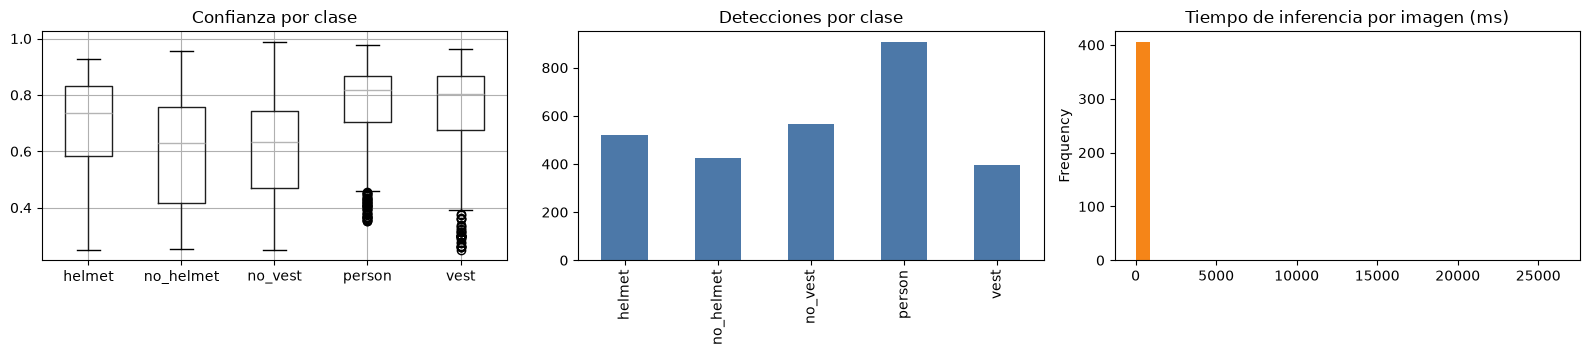

In [6]:
if ready and len(preds):
    fig, ax = plt.subplots(1, 3, figsize=(16, 3.8))
    preds.boxplot(column="confidence", by="model_class", ax=ax[0]); ax[0].set_title("Confianza por clase"); ax[0].set_xlabel("")
    plt.sca(ax[0]); plt.suptitle("")
    pd.Series({k: v["count"] for k, v in q["class_distribution"].items()}).plot.bar(ax=ax[1], color="#4C78A8", title="Detecciones por clase")
    ok = index[index["status"] == "ok"]
    ok["inference_ms"].plot.hist(bins=30, ax=ax[2], color="#F58518", title="Tiempo de inferencia por imagen (ms)")
    plt.tight_layout(); plt.show()

## 3. Segmentación: por cámara, fuente, tipo de evento y severidad

In [7]:
if ready:
    seg = m["segmentation"]
    display(pd.DataFrame(seg["by_camera"]).T)
    print("Fuentes:", seg["n_sources"], "(se listan las 50 con más detecciones)")
    display(pd.DataFrame(seg["by_source"]).T.head(10))
    print("Eventos por tipo:", seg["by_event_type"]); print("Eventos por severidad:", seg["by_severity"])
    print("Periodo:", seg["by_period"])

,frames,detections,events
CAM_01,406,2811,655


Fuentes: 406 (se listan las 50 con más detecciones)


,frames,detections,events
IMG_5846_jpg.rf.ea8c7eabbc61de5b74ae7bb4fc51870e,1,64,10
pos_1221_jpg.rf.0ab3ca84486f26ff6c4e81566e858ef9,1,44,11
thumbnail-ba5c72edb320b49a69e86b05775c49b2-scaled-1_jpeg_jpg.rf.b37d66328fbbd57981fdf8ca7883db9f,1,33,7
006463_jpg.rf.54f788c95e6ecba25f010a1ad84aafab,1,27,9
Image_11_jpg.rf.e3cba4b1ac409befd58dffad3d79e26a,1,27,5
image_from_china-2566-_jpg.rf.b744a5b09decb0b4ff7242fa6514ff78,1,27,9
image_from_china-792-_jpg.rf.1d58056391ab7faf1e4c19f01cfbdf71,1,26,10
image_from_china-2149-_jpg.rf.68f98fc4d9f4d64c58c88103e1cf8bd3,1,25,8
r31_jpg.rf.139f859a5ad39935eb47c1b3d0e52fe1,1,24,8
001963_jpg.rf.50a3e17ab149bbbf196aa5b103166994,1,23,2


Eventos por tipo: {'persona_sin_casco': 117, 'persona_sin_casco_y_chaleco': 323, 'persona_sin_chaleco': 215}
Eventos por severidad: {'alta': 117, 'critica': 323, 'media': 215}
Periodo: {'run_date': '2026-10-09', 'run_hour_utc': 21}


## 4. Trazabilidad

In [8]:
if ready:
    display(pd.Series(m["traceability"], name="valor").astype(str).to_frame())

,valor
weights,models/best_model.pt
weights_sha256,7c7cbfcb6c55c91f3524a21726f86b990acf04d19322c5...
config_hash,6bb983afa7e19a6739d08319b4f90f8751099678edc102...
seed,42
python,3.13.5
platform,Linux-7.0.0-38-generic-x86_64-with-glibc2.39
git_commit,e699dfa2959545586c54b0e02c309efe21e4a8f4
torch,2.14.1+cu126
ultralytics,8.4.174
source,src/data/kaggle_dataset/test/images


## 5. Selección de muestras para el nuevo ciclo

Categorías: errores (FP/FN, si existe `errors.jsonl`), baja confianza, sin detección y alta confianza (control de calidad), estratificadas por cámara y clase.

In [9]:
if ready and RUN_SELECT:
    cmd = [sys.executable, "scripts/select_samples.py", "--run", RUN_DIR, "--out", SAMPLES_CSV, "--n", N_SAMPLES]
    if (Path(EVAL_DIR) / "errors.jsonl").exists():
        cmd += ["--errors", Path(EVAL_DIR) / "errors.jsonl"]
    run(cmd)

$ /home/usuario/Code/Projects/Computer Vision Projects/PPE-detection-using-computer-vision/.venv/bin/python scripts/select_samples.py --run outputs/latest --out reports/next_cycle_samples.csv --n 100 --errors reports/evaluation/errors.jsonl
/home/usuario/Code/Projects/Computer Vision Projects/PPE-detection-using-computer-vision/.venv/bin/python: can't open file '/home/usuario/Code/Projects/Computer Vision Projects/PPE-detection-using-computer-vision/scripts/select_samples.py': [Errno 2] No such file or directory


RuntimeError: El comando falló (código 2). Revisa la salida de arriba.

In [ ]:
if Path(SAMPLES_CSV).exists():
    samples = pd.read_csv(SAMPLES_CSV)
    display(samples.groupby("category").size().rename("muestras").to_frame())
    print("Diversidad (cámara × clase):")
    display(pd.crosstab(samples["camera_id"], samples["class"]))
    display(samples.head(10))

In [ ]:
if Path(SAMPLES_CSV).exists():
    thumbs, titles = [], []
    for cat, grp in samples.groupby("category"):
        for _, r in grp.head(2).iterrows():
            thumbs.append(r["image_path"]); titles.append(f"{cat}: {r['reason']}")
    show_images(thumbs, titles, cols=4, size=(4.2, 3.2))

## 6. Ciclo de mejora (completar para el reporte, sección 8.4)

1. Revisar y corregir las etiquetas de `reports/next_cycle_samples.csv`.
2. Añadirlas al dataset de entrenamiento (sin mezclar con `test`).
3. Reentrenar (`scripts/train.py`), incrementar `model.version` en `configs/inference.yaml`.
4. Reevaluar con el mismo `ground_truth` y comparar métricas entre versiones.

| Versión | mAP@0.5:0.95 | F1 eventos | Cambios |
|---|---|---|---|
| 1.0.0 | _<>_ | _<>_ | modelo base |
| 1.1.0 | _<>_ | _<>_ | _<>_ |